In [1]:
## SMA(5)/SMA(20) Long Strategy Backtest (Multi-Symbol)

# Rules implemented per symbol:
# - Entry: Buy when the 5-day SMA crosses above the 20-day SMA.
# - Exit: Sell when the 5-day SMA decreases vs the prior day.
# - Stop loss: Stop at the low of the entry day.
#
# Data source (per `AGENTS.md`):
# - Load inter-day data via `strategies.data`.
# - `symbols` is a dict keyed by symbol where values are `SymbolData` objects.
# - Each `SymbolData` has `.df` containing OHLCV plus precomputed indicators.

In [2]:
# Setup: imports + optional dependency installs
import sys
import subprocess
import importlib


def ensure_package(pip_name: str, import_name: str | None = None) -> None:
    import_name = import_name or pip_name
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
        importlib.import_module(import_name)


ensure_package("pandas")
ensure_package("numpy")
ensure_package("matplotlib")
ensure_package("backtrader")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import backtrader as bt

from strategies.data import add_market_data_to_syspath, load_daily_variables

pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8")

In [3]:
# Parameters

# Data location
# - If you have a full path to the pickle, set DAILY_VARIABLES_PATH.
# - Otherwise, we load from MARKET_DATA_ROOT\scripts\<filename> (see strategies.utils.config).
DAILY_VARIABLES_PATH = None  # e.g. r"C:\path\to\daily_variables.pkl"
DAILY_VARIABLES_FILENAME = "daily_variables.pkl"

INITIAL_CASH = 100_000.0
COMMISSION = 0.001  # 0.1% per trade



# Load preprocessed inter-day data via strategies.data (per AGENTS.md)
add_market_data_to_syspath()

if DAILY_VARIABLES_PATH:
    from strategies.data import load_pickled_variables

    symbols = load_pickled_variables(DAILY_VARIABLES_PATH)
else:
    symbols = load_daily_variables(filename=DAILY_VARIABLES_FILENAME)

if not isinstance(symbols, dict):
    raise TypeError(f"Expected `symbols` to be a dict, got: {type(symbols)!r}")

available_symbols = sorted(symbols.keys())
if not available_symbols:
    raise ValueError("No symbols loaded from daily variables.")



Loading Variables: 100%|██████████| 26/26 [04:16<00:00,  9.87s/it]  


In [11]:
# Choose symbols to test.
# - Set explicit tickers in TEST_SYMBOLS, e.g. ["NVDA", "AAPL", "MSFT"]
# - Or leave as None to auto-select first AUTO_SYMBOL_COUNT symbols alphabetically.
TEST_SYMBOLS = ["NVDA", "AAPL", "MSFT", "AMZN", "META"]
AUTO_SYMBOL_COUNT = 5

if TEST_SYMBOLS is None:
    selected_symbols = available_symbols[:AUTO_SYMBOL_COUNT]
else:
    selected_symbols = list(dict.fromkeys(TEST_SYMBOLS))

missing_symbols = [s for s in selected_symbols if s not in symbols]
if missing_symbols:
    raise KeyError(
        f"Symbols not found: {missing_symbols}. Example available symbols: {available_symbols[:20]}"
    )

print(f"Selected {len(selected_symbols)} symbols: {selected_symbols}")

Selected 5 symbols: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'META']


In [12]:
# Prepare one Backtrader feed dataframe per symbol using precomputed MA columns

def prepare_feed_df(df_raw: pd.DataFrame, symbol: str) -> tuple[pd.DataFrame, dict]:
    df = df_raw.copy()

    # Ensure DatetimeIndex
    if not isinstance(df.index, pd.DatetimeIndex):
        if "date" in df.columns:
            df["date"] = pd.to_datetime(df["date"])
            df = df.set_index("date")
        else:
            raise TypeError(
                f"{symbol}: Expected SymbolData.df to have a DatetimeIndex (or a `date` column)."
            )

    if getattr(df.index, "tz", None) is not None:
        df.index = df.index.tz_convert(None)

    df = df.sort_index()

    # Normalize column names to lower snake_case
    df = df.rename(columns={c: str(c).lower().replace(" ", "_") for c in df.columns})

    # Prefer close; fall back to adj_close
    if "close" not in df.columns and "adj_close" in df.columns:
        df["close"] = df["adj_close"]

    required = ["open", "high", "low", "close", "volume"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{symbol}: Missing required OHLCV columns: {missing}")

    # Use precomputed 5DMA / 20DMA candidates
    fast_candidates = ["5dma", "sma_5", "ma_5", "dma_5"]
    slow_candidates = ["20dma", "sma_20", "ma_20", "dma_20"]

    fast_col = next((c for c in fast_candidates if c in df.columns), None)
    slow_col = next((c for c in slow_candidates if c in df.columns), None)

    if fast_col is None or slow_col is None:
        ma_like = [c for c in df.columns if "ma" in c or "dma" in c]
        raise ValueError(
            f"{symbol}: Could not find precomputed 5/20 MA columns. "
            f"MA-like columns (sample): {ma_like[:30]}"
        )

    df_feed = df[["open", "high", "low", "close", "volume", fast_col, slow_col]].dropna().copy()
    df_feed = df_feed.rename(columns={fast_col: "ma_fast", slow_col: "ma_slow"})

    # Force numeric dtypes for Backtrader stability
    for col in ["open", "high", "low", "close", "volume", "ma_fast", "ma_slow"]:
        df_feed[col] = pd.to_numeric(df_feed[col], errors="coerce")

    df_feed = df_feed.dropna()
    if df_feed.empty:
        raise ValueError(f"{symbol}: Feed dataframe is empty after cleanup.")

    crossups = (
        (df_feed["ma_fast"] > df_feed["ma_slow"])
        & (df_feed["ma_fast"].shift(1) <= df_feed["ma_slow"].shift(1))
    )

    info = {
        "symbol": symbol,
        "bars": int(len(df_feed)),
        "start": str(df_feed.index.min().date()),
        "end": str(df_feed.index.max().date()),
        "crossups": int(crossups.sum()),
    }
    return df_feed, info


feeds_by_symbol: dict[str, pd.DataFrame] = {}
feed_info: list[dict] = []

for sym in selected_symbols:
    df_raw = symbols[sym].df.copy()
    df_feed, info = prepare_feed_df(df_raw, sym)
    feeds_by_symbol[sym] = df_feed
    feed_info.append(info)

feed_info_df = pd.DataFrame(feed_info).sort_values("symbol").reset_index(drop=True)
feed_info_df

,symbol,bars,start,end,crossups
0,AAPL,2513,2016-02-18,2026-02-13,60
1,AMZN,2513,2016-02-18,2026-02-13,73
2,META,1072,2021-06-30,2026-02-13,30
3,MSFT,2513,2016-02-18,2026-02-13,84
4,NVDA,2513,2016-02-18,2026-02-13,78


In [13]:
# Strategy implementation (Backtrader, multi-symbol)
class TradeCaptureAnalyzer(bt.Analyzer):
    """Collect closed-trade metadata for all symbols."""

    def start(self) -> None:
        self.trades: list[dict] = []

    @staticmethod
    def _safe_history_value(trade, index: int, attr: str):
        try:
            return float(getattr(trade.history[index].event, attr))
        except Exception:
            return None

    def notify_trade(self, trade) -> None:
        if not trade.isclosed:
            return

        data_name = trade.data._name or "UNKNOWN"
        entry_dt = bt.num2date(trade.dtopen)
        exit_dt = bt.num2date(trade.dtclose)

        entry_price = self._safe_history_value(trade, 0, "price")
        exit_price = self._safe_history_value(trade, -1, "price")
        size = self._safe_history_value(trade, 0, "size")

        self.trades.append(
            {
                "symbol": data_name,
                "entry_date": entry_dt.date().isoformat(),
                "exit_date": exit_dt.date().isoformat(),
                "size": size,
                "entry_price": entry_price,
                "exit_price": exit_price,
                "pnl": float(trade.pnlcomm),
            }
        )

    def get_analysis(self):
        return self.trades


class MultiSymbolSmaCrossWithStops(bt.Strategy):
    """Long-only multi-symbol strategy using precomputed MA columns per symbol."""

    params = dict(
        enter_on_start_if_above=True,
        close_on_last_bar=True,
        size_cash_buffer=0.98,
        max_positions=None,  # None => use len(datas)
    )

    def __init__(self) -> None:
        self.ma_fast = {d: d.ma_fast for d in self.datas}
        self.ma_slow = {d: d.ma_slow for d in self.datas}
        self.crossover = {d: bt.ind.CrossOver(self.ma_fast[d], self.ma_slow[d]) for d in self.datas}

        self.state = {
            d: {
                "entry_order": None,
                "last_dt": None,
                "entry_low": None,
                "bars_since_entry": None,
            }
            for d in self.datas
        }

    def start(self) -> None:
        if self.p.close_on_last_bar:
            for d in self.datas:
                self.state[d]["last_dt"] = d.datetime.date(-1)

    def _target_slots(self) -> int:
        if self.p.max_positions is None:
            return max(1, len(self.datas))
        return max(1, int(self.p.max_positions))

    def _calc_size_all_in(self, data) -> int:
        """Allocate roughly 1/N of available cash per new position."""
        price = float(data.close[0])
        if price <= 0:
            return 0

        cash = float(self.broker.getcash())
        if cash <= 0:
            return 0

        slots = self._target_slots()
        budget = (cash * float(self.p.size_cash_buffer)) / slots
        size = int(budget // price)

        comminfo = self.broker.getcommissioninfo(data)
        while size > 0:
            commission = abs(float(comminfo.getcommission(size, price)))
            total_cost = size * price + commission
            if total_cost <= cash:
                break
            size -= 1
        return max(size, 0)

    def nextstart(self) -> None:
        if not self.p.enter_on_start_if_above:
            return

        for d in self.datas:
            st = self.state[d]
            dt = d.datetime.date(0)

            if st["entry_order"] is not None:
                continue

            if st["last_dt"] is not None and dt == st["last_dt"]:
                continue

            if self.getposition(d).size != 0:
                continue

            if self.ma_fast[d][0] > self.ma_slow[d][0]:
                size = self._calc_size_all_in(d)
                if size > 0:
                    st["entry_order"] = self.buy(data=d, size=size)

    def notify_order(self, order) -> None:
        if order.status in [order.Submitted, order.Accepted]:
            return

        d = order.data
        st = self.state[d]

        if order.status in [order.Margin, order.Rejected]:
            dt = d.datetime.date(0)
            print(
                f"ORDER {order.getstatusname()} {d._name} on {dt} | "
                f"isbuy={order.isbuy()} size={order.size} price={order.created.price}"
            )

        if order.status in [order.Canceled, order.Margin, order.Rejected]:
            if order is st["entry_order"]:
                st["entry_order"] = None
            return

        if order.status != order.Completed:
            return

        if order.isbuy():
            st["entry_order"] = None
            st["entry_low"] = float(d.low[0])
            st["bars_since_entry"] = 0

    def next(self) -> None:
        for d in self.datas:
            st = self.state[d]
            dt = d.datetime.date(0)

            if st["entry_order"] is not None:
                continue

            pos = self.getposition(d)

            # Optional forced close on final bar for each symbol.
            if st["last_dt"] is not None and dt == st["last_dt"]:
                if pos.size != 0:
                    self.close(data=d)
                continue

            # No position: check entry condition.
            if pos.size == 0:
                st["entry_low"] = None
                st["bars_since_entry"] = None

                if self.crossover[d][0] > 0:
                    size = self._calc_size_all_in(d)
                    if size > 0:
                        st["entry_order"] = self.buy(data=d, size=size)
                continue

            # Position open: manage exits.
            st["bars_since_entry"] = (
                0 if st["bars_since_entry"] is None else st["bars_since_entry"] + 1
            )

            if st["entry_low"] is not None and float(d.close[0]) < float(st["entry_low"]):
                self.close(data=d)
                continue

            if self.ma_fast[d][0] < self.ma_fast[d][-1]:
                self.close(data=d)
                continue

In [14]:
# Run multi-symbol backtest
cerebro = bt.Cerebro()

cerebro.broker.setcash(INITIAL_CASH)
cerebro.broker.setcommission(commission=COMMISSION)

# Execute market orders on close so sizing uses same-bar close.
cerebro.broker.set_coc(True)


class PandasDataNoOpenInterest(bt.feeds.PandasData):
    lines = ("ma_fast", "ma_slow")
    params = (("openinterest", -1), ("ma_fast", -1), ("ma_slow", -1))


for sym in selected_symbols:
    feed = PandasDataNoOpenInterest(dataname=feeds_by_symbol[sym])
    cerebro.adddata(feed, name=sym)

cerebro.addstrategy(MultiSymbolSmaCrossWithStops)

cerebro.addanalyzer(TradeCaptureAnalyzer, _name="trade_capture")
cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name="tradeanalyzer")
cerebro.addanalyzer(bt.analyzers.TimeReturn, _name="timereturn")
cerebro.addanalyzer(bt.analyzers.DrawDown, _name="drawdown")

start_value = float(cerebro.broker.getvalue())
results = cerebro.run()
strat = results[0]
end_value = float(cerebro.broker.getvalue())

print(f"Symbols: {len(selected_symbols)}")
print(f"Start:   {start_value:,.2f}")
print(f"End:     {end_value:,.2f}")
print(f"Net:     {end_value - start_value:,.2f} ({(end_value / start_value - 1) * 100:.2f}%)")

tradeanalyzer = strat.analyzers.tradeanalyzer.get_analysis()
print("TradeAnalyzer total:", tradeanalyzer.get("total"))

trades = pd.DataFrame(strat.analyzers.trade_capture.get_analysis())
trades.head()

Symbols: 5
Start:   100,000.00
End:     119,583.46
Net:     19,583.46 (19.58%)
TradeAnalyzer total: AutoOrderedDict({'total': 166, 'open': 0, 'closed': 166})


,symbol,entry_date,exit_date,size,entry_price,exit_price,pnl
0,NVDA,2021-07-02,2021-07-09,None,None,None,-338.486041
1,MSFT,2021-07-02,2021-07-13,None,None,None,372.317760
2,AMZN,2021-07-02,2021-07-15,None,None,None,1377.093495
3,AAPL,2021-07-02,2021-07-20,None,None,None,695.839760
4,AAPL,2021-08-05,2021-08-09,None,None,None,-120.236810


In [15]:
# Portfolio equity + equal-weight buy-and-hold benchmark + symbol stats
rets = strat.analyzers.timereturn.get_analysis()
ret_s = pd.Series(rets)
ret_s.index = pd.to_datetime(ret_s.index)
ret_s = ret_s.sort_index()
strategy_equity = (1.0 + ret_s).cumprod() * INITIAL_CASH

# Equal-weight daily-rebalanced benchmark across selected symbols.
close_series = [feeds_by_symbol[s]["close"].rename(s) for s in selected_symbols]
close_df = pd.concat(close_series, axis=1).sort_index()
close_df = close_df.ffill()

bh_daily = close_df.pct_change().fillna(0.0).mean(axis=1, skipna=True)
bh_equity = (1.0 + bh_daily).cumprod() * INITIAL_CASH

# Drawdown stats from Backtrader.
dd = strat.analyzers.drawdown.get_analysis()
max_dd_pct = float(dd.get("max", {}).get("drawdown", np.nan))
max_dd_len = float(dd.get("max", {}).get("len", np.nan))

num_trades = int(len(trades)) if not trades.empty else 0
summary = pd.DataFrame(
    {
        "metric": [
            "symbol_count",
            "strategy_final",
            "strategy_return_%",
            "buyhold_equal_weight_final",
            "buyhold_equal_weight_return_%",
            "max_drawdown_%",
            "max_drawdown_len",
            "num_closed_trades",
        ],
        "value": [
            float(len(selected_symbols)),
            float(strategy_equity.iloc[-1]) if not strategy_equity.empty else np.nan,
            float((strategy_equity.iloc[-1] / INITIAL_CASH - 1) * 100) if not strategy_equity.empty else np.nan,
            float(bh_equity.iloc[-1]) if not bh_equity.empty else np.nan,
            float((bh_equity.iloc[-1] / INITIAL_CASH - 1) * 100) if not bh_equity.empty else np.nan,
            max_dd_pct,
            max_dd_len,
            num_trades,
        ],
    }
)

if not trades.empty:
    symbol_trade_summary = (
        trades.groupby("symbol", as_index=False)
        .agg(num_trades=("pnl", "count"), total_pnl=("pnl", "sum"), avg_pnl=("pnl", "mean"))
        .sort_values("total_pnl", ascending=False)
        .reset_index(drop=True)
    )
else:
    symbol_trade_summary = pd.DataFrame(columns=["symbol", "num_trades", "total_pnl", "avg_pnl"])

print("=== Portfolio Summary ===")
display(summary)
print("=== Per-Symbol Trade Summary ===")
display(symbol_trade_summary)
print("=== Sample Closed Trades ===")
display(trades.head(20))

=== Portfolio Summary ===


,metric,value
0,symbol_count,5.000000e+00
1,strategy_final,1.195835e+05
2,strategy_return_%,1.958346e+01
3,buyhold_equal_weight_final,6.615655e+06
4,buyhold_equal_weight_return_%,6.515655e+03
5,max_drawdown_%,1.051478e+01
6,max_drawdown_len,2.970000e+02
7,num_closed_trades,1.660000e+02


=== Per-Symbol Trade Summary ===


,symbol,num_trades,total_pnl,avg_pnl
0,NVDA,37,10262.847756,277.374264
1,META,29,8578.696760,295.817130
2,AAPL,32,1395.865730,43.620804
3,MSFT,39,269.246520,6.903757
4,AMZN,29,-923.197559,-31.834399


=== Sample Closed Trades ===


,symbol,entry_date,exit_date,size,entry_price,exit_price,pnl
0,NVDA,2021-07-02,2021-07-09,None,None,None,-338.486041
1,MSFT,2021-07-02,2021-07-13,None,None,None,372.317760
2,AMZN,2021-07-02,2021-07-15,None,None,None,1377.093495
3,AAPL,2021-07-02,2021-07-20,None,None,None,695.839760
4,AAPL,2021-08-05,2021-08-09,None,None,None,-120.236810
5,NVDA,2021-08-04,2021-08-12,None,None,None,-156.913626
6,META,2021-08-05,2021-08-12,None,None,None,-54.016060
7,AAPL,2021-08-13,2021-08-19,None,None,None,-375.758250
8,NVDA,2021-08-24,2021-09-08,None,None,None,596.738900
9,META,2021-08-26,2021-09-10,None,None,None,137.977400


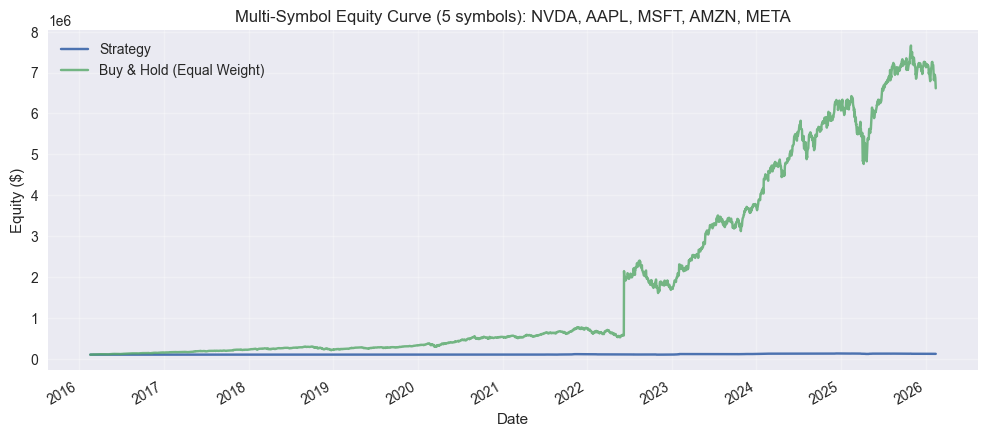

In [9]:
# Plot portfolio strategy equity vs equal-weight benchmark
fig, ax = plt.subplots(figsize=(12, 5))
strategy_equity.plot(ax=ax, label="Strategy")
bh_equity.plot(ax=ax, label="Buy & Hold (Equal Weight)", alpha=0.8)

symbol_label = ", ".join(selected_symbols[:8])
if len(selected_symbols) > 8:
    symbol_label += ", ..."

ax.set_title(f"Multi-Symbol Equity Curve ({len(selected_symbols)} symbols): {symbol_label}")
ax.set_ylabel("Equity ($)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [10]:
# Optional: Backtrader's built-in price/indicator plot
# (Can be slow with multiple symbols / long date ranges.)
# cerebro.plot(iplot=False, volume=False, style="candlestick")